In [2]:
library(ComplexHeatmap)
library(dplyr)
library(RColorBrewer)
library(circlize)  
library(dendextend) 
library(NbClust)
library(ggplot2)
library(ggpubr)
library(tidyr)
library(viridis)
library(readxl)

Warning message:
“package ‘ComplexHeatmap’ was built under R version 4.3.2”
Loading required package: grid

ComplexHeatmap version 2.18.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, u

In [ ]:
load("/vol/projects/yzhang/500FG_aging/output/14_AA/heatmap_500fg_bar_zscore_spears_sig_feature_gender_nature.Rdata")

In [1]:
cytokine <- read.csv("/vol/projects/yzhang/500FG_aging/input/cytokine/filtered_cytokine_filled_trans.csv",row.names=1)
head(cytokine)
dim(cytokine)

protein <- readRDS("/vol/projects/CIIM/cohorts_old/500FG/olinkData/NPX_FG500.RDS")
head(protein)
dim(protein)

basicPhenos = read.csv("/vol/projects/yzhang/500FG_aging/output/02_Olink/Age_group_basicPhenos.csv",row.names=1)
head(basicPhenos)
dim(basicPhenos)

,IFNy_LPS_WB_48h,IFNy_PHA_WB_48h,IFNy_C.conidiaHK_WB_48h,IFNy_S.aureus_WB_48h,IL1b_LPS_WB_48h,IL1b_PHA_WB_48h,IL1b_C.conidiaHK_WB_48h,IL1b_S.aureus_WB_48h,IL6_LPS_WB_48h,IL6_PHA_WB_48h,⋯,IL22_Cryptococcus_PBMC_7days,IL22_Bacteroides_PBMC_7days,IL6_LPS_macroPG_24h,IL6_C.albicansconidia_macroPG_24h,IL6_MTB_macroPG_24h,IL6_S.typhimurium_macroPG_24h,TNFA_LPS_macroPG_24h,TNFA_C.albicansconidia_macroPG_24h,TNFA_MTB_macroPG_24h,TNFA_S.typhimurium_macroPG_24h
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV001,10.828930,10.710806,8.965784,10.366322,11.34541,10.595257,8.392317,10.051209,13.26033,13.03480,⋯,NA,8.290019,8.335390,7.936638,8.005625,10.152285,7.459432,8.326429,6.285402,9.417853
HV002,9.457381,8.761551,9.511753,9.651052,11.43359,9.652845,8.558421,9.162391,13.74431,12.81238,⋯,NA,10.594325,10.156083,9.703904,9.142107,4.954196,8.927778,9.579316,7.149747,6.285402
HV003,8.413628,10.884934,5.857981,8.442943,11.03480,10.098032,7.475733,9.321928,12.89045,12.62708,⋯,NA,11.640697,8.467606,8.857981,8.927778,10.637531,9.592457,10.224002,8.654636,11.734710
HV004,5.643856,5.285402,5.285402,5.426265,10.69697,8.894818,10.008429,9.238405,13.48533,13.11586,⋯,NA,11.611486,8.224002,7.851749,9.079485,10.795228,8.129283,8.654636,7.781360,10.781360
HV005,8.957102,8.179909,5.700440,7.459432,10.68299,9.105909,7.475733,9.396605,13.04405,12.66977,⋯,NA,NA,7.845490,6.149747,7.864186,9.829723,6.285402,7.149747,6.507795,9.529431
HV006,8.774787,6.727920,5.781360,7.483816,10.22641,7.599913,6.266787,8.761551,12.75572,12.06205,⋯,NA,10.087463,7.876517,7.303781,8.921841,10.710806,7.930737,7.375039,7.149747,9.946906


[1] 489  91

,IL8,VEGFA,CD8A,CDCP1,CD244,IL7,OPG,LAP_TGF_beta_1,uPA,IL6,⋯,CX3CL1,TNFRSF9,NT_3,TWEAK,CCL20,ST1A1,STAMBP,ADA,TNFB,CSF_1
HV001,3.63611,9.48365,9.52098,2.30522,7.29957,2.53580,9.68034,6.69739,9.83187,2.65429,⋯,5.09046,6.45090,2.70225,9.03842,8.68959,3.22945,4.78947,4.93394,4.44519,9.53556
HV002,4.31364,9.69720,10.49119,1.97309,7.34675,3.16577,10.23258,7.63274,10.44883,2.01410,⋯,5.44641,6.73492,2.76555,9.75981,6.22762,4.50936,5.30881,5.22062,4.81664,9.72443
HV003,4.06539,10.19810,9.57446,2.28619,7.46174,2.91413,10.33496,7.45751,9.80417,3.37359,⋯,6.08994,6.77356,2.77692,8.77353,6.15381,4.79457,5.47104,5.15920,5.64723,10.37471
HV004,3.20146,9.97967,7.86780,2.22472,6.33368,2.29093,9.83527,6.53851,9.56768,3.32486,⋯,5.59638,6.68823,2.44064,8.87093,5.66952,4.72120,4.61117,5.74346,5.96514,10.25552
HV005,4.28828,10.10370,11.63828,2.26651,7.93486,3.32575,9.80797,7.58017,10.16342,2.64213,⋯,6.07405,7.26541,2.69546,9.52142,7.18970,4.65843,5.87574,5.37253,5.17238,9.85607
HV006,4.21672,10.11105,11.17692,2.53762,7.29801,2.96055,10.59224,6.94480,10.04118,2.97745,⋯,6.00473,7.15083,2.69737,9.67547,6.45433,3.70019,4.68181,5.17577,5.08267,9.98597


[1] 424  70

,ID_500fg,Gender,Age,Height,Weight,BMI,LivingSituation,Education,Ethnicity,FarmAnimal,Pets,Travel,DayInMonth,monthinYear,dayInYear,year,AgeGroup
,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>
2,HV043,male,18,182,50,15.09480,Married,University student,European,Rarely,Yes,Yes,16,12,346,2013,Group 1
16,HV515,male,18,170,62,21.45329,Cohabitation,University student,European,Once a month,No,Yes,8,12,338,2014,Group 1
41,HV518,male,18,180,67,20.67901,Single living alone,University student,European,Rarely,No,No,1,12,331,2014,Group 1
51,HV314,male,18,181,74,22.58783,Married,Middelbaar beroepsonderwijs (MBO),European,Never,No,No,24,11,324,2014,Group 1
56,HV497,female,18,157,49,19.87910,Married,Hogeschool opleiding (HBO),Asian,Rarely,No,No,24,11,324,2014,Group 1
148,HV454,female,18,167,50,17.92822,Married,University student,European,Rarely,No,Yes,20,10,290,2014,Group 1


[1] 527  17

In [3]:
cytokine_sig <- read.csv("/vol/projects/yzhang/500FG_aging/output/01_cytokine/cytokine_age_liner_gender_FDR.csv",row.names=1)
head(cytokine_sig)
dim(cytokine_sig)

protein_sig <- read.csv("/vol/projects/yzhang/500FG_aging/output/02_Olink/olink_age_liner_gender_FDR.csv",row.names=1)
head(protein_sig)
dim(protein_sig)

,feature,estimate,p,value,padj,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Estimate,IFNy_LPS_WB_48h,-1.489589e-03,0.0157429534,-2.685600e-03,0.057304350,no
Estimate1,IFNy_PHA_WB_48h,-1.248407e-03,0.1019912047,-1.237717e-03,0.257610692,no
Estimate2,IFNy_C.conidiaHK_WB_48h,-2.449299e-03,0.0004847994,-8.118050e-03,0.002757296,sig
Estimate3,IFNy_S.aureus_WB_48h,-1.828313e-03,0.0112181557,-3.565355e-03,0.050387503,no
Estimate4,IL1b_LPS_WB_48h,1.086956e-04,0.5573738995,2.759275e-05,0.768500377,no
Estimate5,IL1b_PHA_WB_48h,-9.867128e-05,0.8021676676,-9.446280e-06,0.912465722,no


[1] 91  6

,feature,estimate,p,value,padj,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Estimate,IL8,1.857226e-03,1.605897e-07,1.261852e-02,1.405159e-06,sig
Estimate1,VEGFA,3.326290e-04,2.074781e-03,8.924529e-04,6.051445e-03,sig
Estimate2,CD8A,-1.732231e-03,1.947852e-06,-9.891808e-03,1.136247e-05,sig
Estimate3,CDCP1,8.233146e-03,1.164648e-42,3.452471e-01,8.152538e-41,sig
Estimate4,CD244,-1.948333e-05,9.125587e-01,-7.742512e-07,9.257842e-01,no
Estimate5,IL7,1.341586e-03,3.960574e-02,1.881228e-03,7.108723e-02,no


[1] 70  6

In [4]:
cytokine_sig <- cytokine_sig[cytokine_sig$sig=="sig",]
cytokine_features <- cytokine_sig$feature
cytokine_filtered <- cytokine[, colnames(cytokine) %in% cytokine_features]
head(cytokine_filtered)
dim(cytokine_filtered)

protein_sig <- protein_sig[protein_sig$sig == "sig", ]
protein_features <- protein_sig$feature
protein_filtered <- protein[, colnames(protein) %in% protein_features]
head(protein_filtered)
dim(protein_filtered)

,IFNy_C.conidiaHK_WB_48h,IL6_PHA_WB_48h,IL6_C.albicanshyphae_PBMC_24h,IL6_A.fumigatusconidiaSerum_PBMC_24h,IFNy_B.burgdorferi_PBMC_7days,IFNy_Borreliamix_PBMC_7days,IFNy_C.albicansconidia_PBMC_7days,IFNy_C.albicanshyphae_PBMC_7days,IFNy_MTB_PBMC_7days,IFNy_S.aureus_PBMC_7days,IFNy_Bacteroides_PBMC_7days,IL17_Bacteroides_PBMC_7days,IL22_B.burgdorferi_PBMC_7days,IL22_Borreliamix_PBMC_7days,IL22_C.albicansconidia_PBMC_7days,IL22_C.albicanshyphae_PBMC_7days,IL22_MTB_PBMC_7days,IL22_S.aureus_PBMC_7days,IL22_Bacteroides_PBMC_7days
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV001,8.965784,13.03480,7.285402,9.876517,12.287712,5.357552,7.614710,8.149747,5.643856,6.303781,7.022368,8.550747,14.28771,10.14720,10.900112,11.40514,10.342075,8.290019,8.290019
HV002,9.511753,12.81238,8.280771,9.712527,8.049849,7.734710,5.882643,6.845490,6.066089,7.276124,9.308339,8.214319,12.32867,12.07915,9.527477,10.02375,10.389094,7.434628,10.594325
HV003,5.857981,12.62708,NA,NA,11.421539,9.216746,5.285402,5.807355,6.700440,9.264443,10.294621,8.581201,14.10558,11.71296,8.679480,10.75238,11.563196,9.361944,11.640697
HV004,5.285402,13.11586,NA,NA,12.287712,8.607330,5.285402,7.055282,5.285402,8.980140,12.202430,6.285402,14.28771,13.72249,8.800900,10.42206,11.369052,10.174926,11.611486
HV005,5.700440,12.66977,7.426265,7.851749,6.569856,9.743151,5.857981,5.832890,7.055282,10.326429,7.033423,7.459432,10.10591,11.45430,10.149747,10.16491,NA,NA,NA
HV006,5.781360,12.06205,NA,NA,12.287712,8.924813,5.491853,7.936638,7.857981,9.632995,12.255029,9.197217,14.28771,11.98050,10.506803,10.07146,9.501837,8.721099,10.087463


[1] 489  19

,IL8,VEGFA,CD8A,CDCP1,OPG,LAP_TGF_beta_1,IL6,MCP_1,CXCL11,CXCL9,⋯,CXCL10,CCL28,CD40,MCP_2,CASP_8,CCL25,CX3CL1,TNFRSF9,NT_3,TNFB
HV001,3.63611,9.48365,9.52098,2.30522,9.68034,6.69739,2.65429,10.45254,7.44738,6.02191,⋯,8.36986,1.84040,11.44100,7.99089,2.57231,5.36536,5.09046,6.45090,2.70225,4.44519
HV002,4.31364,9.69720,10.49119,1.97309,10.23258,7.63274,2.01410,10.74596,7.27919,6.03007,⋯,8.15846,1.78795,11.19810,8.41194,3.22599,5.76616,5.44641,6.73492,2.76555,4.81664
HV003,4.06539,10.19810,9.57446,2.28619,10.33496,7.45751,3.37359,10.71738,7.45611,6.76316,⋯,10.09625,1.76763,12.02764,7.39405,3.19766,5.16156,6.08994,6.77356,2.77692,5.64723
HV004,3.20146,9.97967,7.86780,2.22472,9.83527,6.53851,3.32486,10.31810,6.10018,6.16359,⋯,9.09970,1.16293,10.88593,7.98752,2.42345,6.31634,5.59638,6.68823,2.44064,5.96514
HV005,4.28828,10.10370,11.63828,2.26651,9.80797,7.58017,2.64213,10.72627,7.04801,6.38919,⋯,8.56685,2.21728,11.60948,7.83547,3.95433,5.81332,6.07405,7.26541,2.69546,5.17238
HV006,4.21672,10.11105,11.17692,2.53762,10.59224,6.94480,2.97745,10.77937,7.32848,6.85715,⋯,9.55948,1.79223,11.02686,8.27947,2.93375,5.02830,6.00473,7.15083,2.69737,5.08267


[1] 424  37

In [5]:
common_samples <- intersect(intersect(rownames(cytokine_filtered), 
                                      rownames(protein_filtered)), 
                            basicPhenos$ID_500fg)

# Filter out common samples
cytokine_common <- cytokine_filtered[common_samples, , drop = FALSE]
protein_common <- protein_filtered[common_samples, , drop = FALSE]
basicPhenos_common <- basicPhenos[basicPhenos$ID_500fg %in% common_samples, , drop = FALSE]

# Reset row names of basicPhenos_filtered to match common_samples
rownames(basicPhenos_common) <- basicPhenos_common$ID_500fg

# Ensure basicPhenos_filtered only contains common samples
basicPhenos_common <- basicPhenos_common[common_samples, , drop = FALSE]

# Merge data (retain all features)
merged_data <- data.frame(
  Sample_ID = common_samples,
  Age = basicPhenos_common$Age,  # Age alignment
  cytokine_common,  # All cytokine features
  protein_common    # All protein features
)

# View merged data
head(merged_data)
dim(merged_data)

,Sample_ID,Age,IFNy_C.conidiaHK_WB_48h,IL6_PHA_WB_48h,IL6_C.albicanshyphae_PBMC_24h,IL6_A.fumigatusconidiaSerum_PBMC_24h,IFNy_B.burgdorferi_PBMC_7days,IFNy_Borreliamix_PBMC_7days,IFNy_C.albicansconidia_PBMC_7days,IFNy_C.albicanshyphae_PBMC_7days,⋯,CXCL10,CCL28,CD40,MCP_2,CASP_8,CCL25,CX3CL1,TNFRSF9,NT_3,TNFB
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV001,HV001,27,8.965784,13.03480,7.285402,9.876517,12.287712,5.357552,7.614710,8.149747,⋯,8.36986,1.84040,11.44100,7.99089,2.57231,5.36536,5.09046,6.45090,2.70225,4.44519
HV002,HV002,26,9.511753,12.81238,8.280771,9.712527,8.049849,7.734710,5.882643,6.845490,⋯,8.15846,1.78795,11.19810,8.41194,3.22599,5.76616,5.44641,6.73492,2.76555,4.81664
HV003,HV003,24,5.857981,12.62708,NA,NA,11.421539,9.216746,5.285402,5.807355,⋯,10.09625,1.76763,12.02764,7.39405,3.19766,5.16156,6.08994,6.77356,2.77692,5.64723
HV004,HV004,20,5.285402,13.11586,NA,NA,12.287712,8.607330,5.285402,7.055282,⋯,9.09970,1.16293,10.88593,7.98752,2.42345,6.31634,5.59638,6.68823,2.44064,5.96514
HV005,HV005,22,5.700440,12.66977,7.426265,7.851749,6.569856,9.743151,5.857981,5.832890,⋯,8.56685,2.21728,11.60948,7.83547,3.95433,5.81332,6.07405,7.26541,2.69546,5.17238
HV006,HV006,24,5.781360,12.06205,NA,NA,12.287712,8.924813,5.491853,7.936638,⋯,9.55948,1.79223,11.02686,8.27947,2.93375,5.02830,6.00473,7.15083,2.69737,5.08267


[1] 407  58

In [6]:
write.csv(merged_data,"/vol/projects/yzhang/500FG_aging/output/14_AA/500fg_heatmap_merge_data_gender.csv",row.names=TRUE)

In [7]:
protein_cyto_sig_feature <- colnames(merged_data)
protein_cyto_sig_feature <- protein_cyto_sig_feature[-c(1, 2)]
head(protein_cyto_sig_feature)
length(protein_cyto_sig_feature)
#write.csv(protein_cyto_sig_feature,"/vol/projects/yzhang/500FG_aging/output/14_AA/protein_cyto_sig_feature.csv")

[1] "IFNy_C.conidiaHK_WB_48h"             
[2] "IL6_PHA_WB_48h"                      
[3] "IL6_C.albicanshyphae_PBMC_24h"       
[4] "IL6_A.fumigatusconidiaSerum_PBMC_24h"
[5] "IFNy_B.burgdorferi_PBMC_7days"       
[6] "IFNy_Borreliamix_PBMC_7days"

[1] 56

In [8]:
##deal with missing value
sum(is.na(merged_data))
merged_data <- merged_data %>%
  mutate(across(where(is.numeric), ~ ifelse(is.na(.), mean(., na.rm = TRUE), .)))
sum(is.na(merged_data))

[1] 146

[1] 0

Warning message:
“There was 1 warning in `summarise()`.
ℹ In argument: `across(everything(), median, na.rm = TRUE)`.
ℹ In group 1: `Age = 18`.
Caused by warning:
! The `...` argument of `across()` is deprecated as of dplyr 1.1.0.
Supply arguments directly to `.fns` through an anonymous function instead.

  # Previously
  across(a:b, mean, na.rm = TRUE)

  # Now
  across(a:b, \(x) mean(x, na.rm = TRUE))”


pdf 
  2

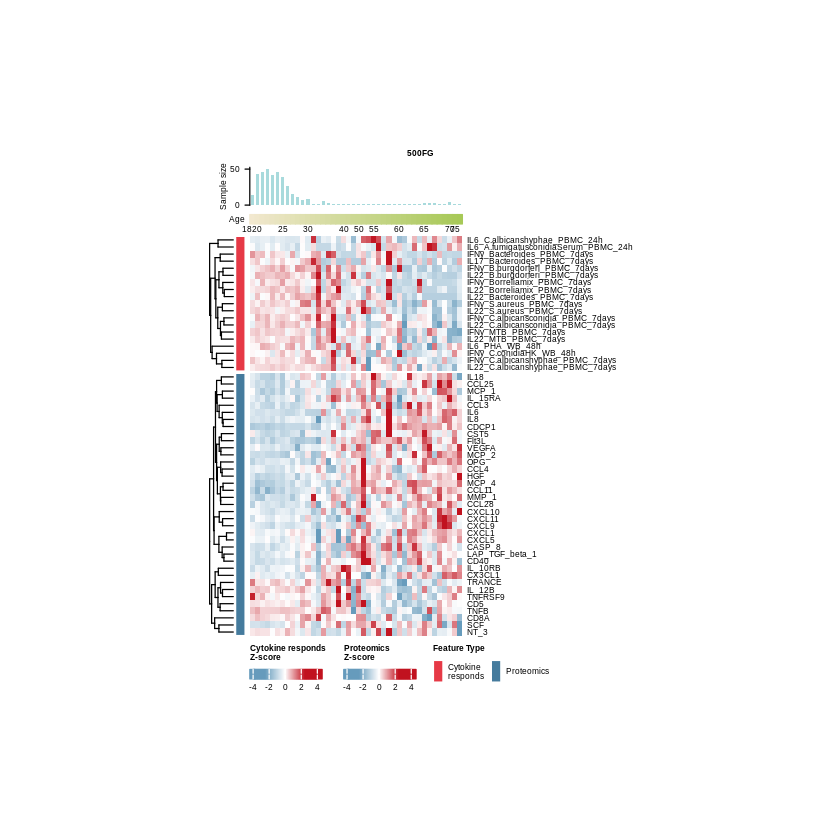

In [9]:
##nature style
# Prepare heatmap data (exclude Sample_ID and Age columns)
heatmap_data <- merged_data[, !(colnames(merged_data) %in% c("Sample_ID", "Age"))]

# Sort data by age
sorted_indices <- order(merged_data$Age, na.last = FALSE)
heatmap_data_sorted <- heatmap_data[sorted_indices, , drop = FALSE]
age_sorted <- merged_data$Age[sorted_indices]

# Group by age and calculate median values
heatmap_data_grouped <- heatmap_data_sorted %>%
  mutate(Age = age_sorted) %>%
  group_by(Age) %>%
  summarise(across(everything(), median, na.rm = TRUE)) %>%
  ungroup() %>%
  arrange(Age)

# Extract final data for heatmap
age_sorted <- heatmap_data_grouped$Age
heatmap_data_grouped <- as.matrix(select(heatmap_data_grouped, -Age))

# Transpose data matrix (features as rows, age groups as columns)
heatmap_data_transposed <- t(heatmap_data_grouped)

# Separate cytokine and protein data
cytokine_colnames <- colnames(cytokine_common)
protein_colnames <- colnames(protein_common)
feature_types <- c(rep("Cytokine stimulus pair", length(cytokine_colnames)), 
                   rep("Protein", length(protein_colnames)))

cytokine_indices <- which(feature_types == "Cytokine stimulus pair")
protein_indices <- which(feature_types == "Protein")

cytokine_data <- heatmap_data_transposed[cytokine_indices, , drop = FALSE]
protein_data <- heatmap_data_transposed[protein_indices, , drop = FALSE]

# Z-score normalization function
zscore_data <- function(data_matrix) {
  zscore_matrix <- t(apply(data_matrix, 1, function(x) {
    (x - mean(x, na.rm = TRUE)) / sd(x, na.rm = TRUE)
  }))
  return(zscore_matrix)
}

# Apply Z-score normalization to each feature type
cytokine_data_zscore <- zscore_data(cytokine_data)
protein_data_zscore <- zscore_data(protein_data)

# Age color mapping
age_col_fun <- colorRamp2(
  quantile(age_sorted, probs = seq(0, 1, length.out = 100)),
  colorRampPalette(c("#f2e8cf", "#a7c957"))(100)
)

# Calculate sample counts for each age group
age_counts <- as.data.frame(table(merged_data$Age))
colnames(age_counts) <- c("Age", "Count")
age_counts$Age <- as.numeric(as.character(age_counts$Age))
age_counts_sorted <- age_counts[match(age_sorted, age_counts$Age), ]
sample_counts <- ifelse(is.na(age_counts_sorted$Count), 0, age_counts_sorted$Count)

# Create age labels with sample counts
age_labels <- ifelse(
  age_sorted %in% c(min(age_sorted), max(age_sorted)) | age_sorted %% 5 == 0, 
  #paste0(as.character(age_sorted), " (n=", sample_counts, ")"),
   as.character(age_sorted), 
  ""
)
# ========== Change 1: Add one line (Nature-style font, 6 pt) ==========
font_pt <- 5
row_height_mm <- 1.5 
heatmap_width_mm <- 45

##z-score
cytokine_zscore_range <- range(cytokine_data_zscore, na.rm = TRUE)
protein_zscore_range  <- range(protein_data_zscore,  na.rm = TRUE)

max_cytokine_abs <- max(abs(cytokine_zscore_range))
max_protein_abs  <- max(abs(protein_zscore_range))

cytokine_limit <- min(max_cytokine_abs, 2.5)
protein_limit  <- min(max_protein_abs,  2.5)

cytokine_col_fun <- colorRamp2(
  seq(-cytokine_limit, cytokine_limit, length.out = 100),
  colorRampPalette(c("#669bbc", "white", "#c1121f"))(100)
)
protein_col_fun <- colorRamp2(
  seq(-protein_limit, protein_limit, length.out = 100),
  colorRampPalette(c("#669bbc", "white", "#c1121f"))(100)
)


#age_labels[age_sorted == 70] <- "" #hide 70，overlap in the fig
# ========== Change 2: Add/update these in Heatmap() ==========
# Create cytokine heatmap
cytokine_heatmap <- Heatmap(
  cytokine_data_zscore,
  name = "Cytokine responds\nZ-score",
  cluster_rows = TRUE,
  cluster_columns = FALSE,
  show_row_names = TRUE,
  show_column_names = FALSE,
  row_names_gp = gpar(fontsize = font_pt),              # ADD
  column_names_gp = gpar(fontsize = font_pt),           # ADD
  col = cytokine_col_fun,
  row_dend_reorder = FALSE,
  row_dend_width = unit(5, "mm"),
    width = unit(heatmap_width_mm, "mm"),
    height = unit(nrow(cytokine_data_zscore) * row_height_mm, "mm"),
  top_annotation = HeatmapAnnotation(
    Age = anno_simple(age_sorted, col = age_col_fun, height = unit(2, "mm")),
    Age_Label = anno_text(age_labels, gp = gpar(fontsize = font_pt), rot = 0),
    annotation_name_side = "left",
    annotation_name_gp = gpar(fontsize = font_pt)
  ),
  left_annotation = rowAnnotation(
    Feature_Type = anno_block(
      gp = gpar(fill = "#e63946", col = "white"),
      width = unit(2, "mm")
    )
  ),
  rect_gp = gpar(col = NA),
  border = FALSE,
    heatmap_legend_param = list(                          # ADD this block
    title_gp = gpar(fontsize = font_pt, fontface = "bold"),
    labels_gp = gpar(fontsize = font_pt),
      direction = "horizontal",
    legend_width = unit(15, "mm"),          
    grid_height = unit(2, "mm")    
)
)
# Create protein heatmap
protein_heatmap <- Heatmap(
  protein_data_zscore,
  name = "Proteomics\nZ-score",
  cluster_rows = TRUE,
  cluster_columns = FALSE,
  show_row_names = TRUE,
  show_column_names = TRUE,
  row_names_gp = gpar(fontsize = font_pt),              # ADD
  column_names_gp = gpar(fontsize = font_pt),           # ADD
  col = protein_col_fun,
  row_dend_reorder = FALSE,
    row_dend_width = unit(5, "mm"),
    width = unit(heatmap_width_mm, "mm"),
    height = unit(nrow(protein_data_zscore) * row_height_mm, "mm"),
  left_annotation = rowAnnotation(
    Feature_Type = anno_block(
      gp = gpar(fill = "#457b9d", col = "white"),
      width = unit(2, "mm")
    )
  ),
  rect_gp = gpar(col = NA),
  border = FALSE,
    heatmap_legend_param = list(                          # ADD this block
    title_gp = gpar(fontsize = font_pt, fontface = "bold"),
    labels_gp = gpar(fontsize = font_pt),
      direction = "horizontal",
    legend_width = unit(15, "mm"),          
    grid_height = unit(2, "mm")    
)
)
# ========== Change 3: Feature Type legend font ==========
feature_type_legend_separate <- Legend(
  title = "Feature Type",
  title_gp = gpar(fontsize = font_pt, fontface = "bold"),
  at = c("Cytokine\nresponds","Proteomics"),
  legend_gp = gpar(fill = c("#e63946","#457b9d")),
  labels_gp = gpar(fontsize = font_pt),
  grid_width = unit(2, "mm"),
    ncol = 2
)

# ========== Change 4: Sample count axis font ==========
sample_count_anno <- HeatmapAnnotation(
   `Sample size` = anno_barplot(
    sample_counts,
    gp = gpar(fill = "#a8dadc", col = NA, lwd = 0),
    height = unit(0.8, "cm"),
    axis_param = list(
      at = c(0, max(sample_counts)),
      labels = c("0", max(sample_counts)),
      gp = gpar(fontsize = font_pt)
    ),
    border = FALSE
  ),
  annotation_name_side = "left",
  annotation_name_gp = gpar(fontsize = font_pt)
)

heatmap_combined_separate <- sample_count_anno %v% (cytokine_heatmap %v% protein_heatmap)


# ========== Change 5: PDF size (Nature double-column) ==========
pdf("/vol/projects/yzhang/500FG_aging/output/14_AA/heatmap_500fg_bar_zscore_spears_sig_feature_gender_nature.pdf", width = 3.62, height = 5.2, onefile = FALSE)

# draw() must be assigned so row_order() gets the initialized list (avoids warning)
ht_drawn <- draw(
  heatmap_combined_separate,
  column_title = "500FG",
  column_title_side = "top",
  column_title_gp = gpar(fontsize = font_pt, fontface = "bold"),
  show_heatmap_legend = TRUE,
  show_annotation_legend = TRUE,
  annotation_legend_list = list(feature_type_legend_separate),
  heatmap_legend_side = "bottom",
  annotation_legend_side = "bottom",
  merge_legends = TRUE,
  align_heatmap_legend = "heatmap_center",
  legend_title_gp = gpar(fontsize = font_pt, fontface = "bold"),
  legend_labels_gp = gpar(fontsize = font_pt),
  ht_gap = unit(c(2, 0.5), "mm")
)

# Export clustered row order from the drawn object (required for correct order)
row_orders <- row_order(ht_drawn)
cytokine_row_order <- rownames(cytokine_data_zscore)[row_orders[[1]]]
protein_row_order  <- rownames(protein_data_zscore)[row_orders[[2]]]
saveRDS(list(cytokine = cytokine_row_order, protein = protein_row_order),
        "/vol/projects/yzhang/500FG_aging/output/14_AA/heatmap_500fg_cyto_pro_row_gender_order.rds")
dev.off()

#29. **Display separate version on screen**
draw(
  heatmap_combined_separate,
  column_title = "500FG",                    
  column_title_side = "top",
  column_title_gp = gpar(fontsize = font_pt, fontface = "bold"),
  show_heatmap_legend = TRUE,
  show_annotation_legend = TRUE,
   annotation_legend_list = list(feature_type_legend_separate),
  heatmap_legend_side = "bottom",
  annotation_legend_side = "bottom",
  merge_legends = TRUE,
  legend_title_gp = gpar(fontsize = font_pt, fontface = "bold"),
  legend_labels_gp = gpar(fontsize = font_pt),
  ht_gap = unit(c(2, 0.5), "mm")
)

In [10]:
save.image("/vol/projects/yzhang/500FG_aging/output/14_AA/heatmap_500fg_bar_zscore_spears_sig_feature_gender_nature.Rdata")

out_500fg <- list(
  cytokine_data = cytokine_data,   
  protein_data  = protein_data,
  sample_counts = sample_counts,
  age_sorted = age_sorted,
  age_labels = age_labels,
  age_col_fun = age_col_fun, 
  cytokine_col_fun = cytokine_col_fun,
  protein_col_fun = protein_col_fun,
  cytokine_limit = cytokine_limit,
  protein_limit = protein_limit
)
saveRDS(out_500fg, "/vol/projects/yzhang/500FG_aging/output/14_AA/heatmap_500fg_nature.rds")

In [11]:
###protein tissue link
protein_tissue <- read_excel("/vol/projects/yzhang/500FG_aging/input/olink/protein_cyto_sig_feature_tissue.xlsx")
protein_tissue <- protein_tissue[-c(1:20),]
head(protein_tissue)
dim(protein_tissue)
table(protein_tissue$GtexOrgan)

Feature,GtexOrgan,Target_gene
<chr>,<chr>,<chr>
IL8,Immune,CXCL8
VEGFA,Thyroid,NA
CD8A,Immune,NA
CDCP1,Esophagus,NA
OPG,Artery,TNFRSF11B
LAP_TGF_beta_1,Immune,TGFB1


[1] 40  3


  Adipose    Artery     Brain Esophagus    Female    Immune Intestine    Kidney 
        1         3         2         3         2        10         5         1 
     Lung      Male Pituitary  Salivary      Skin   Stomach   Thyroid 
        5         2         1         2         1         1         1 

pdf 
  2

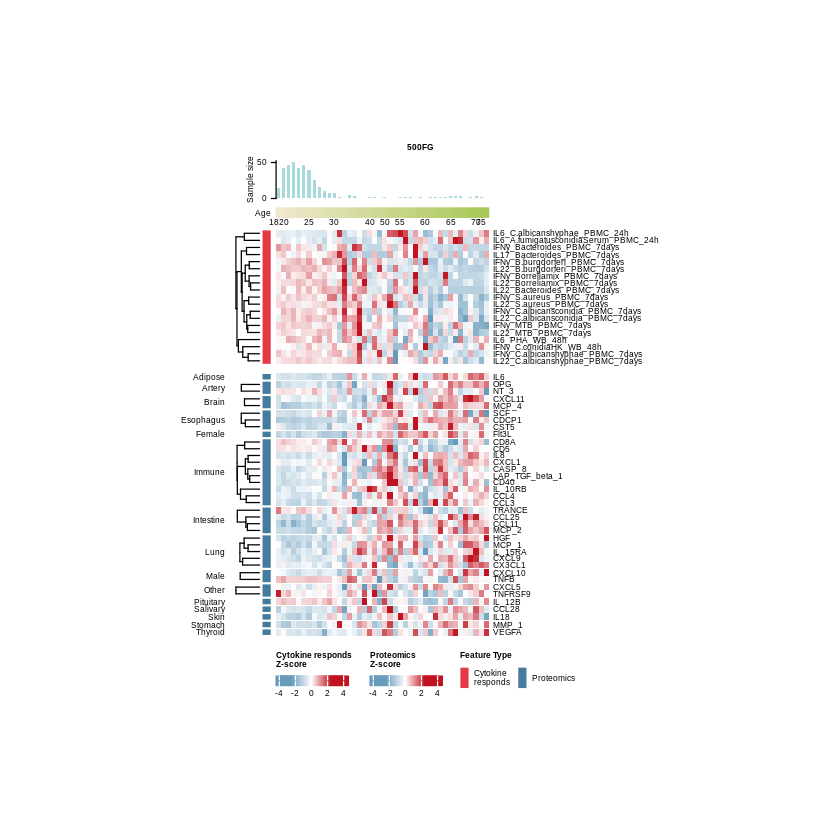

In [20]:
## Heatmap (tissue cluster) + Nature-style layout
# Prepare heatmap data (exclude Sample_ID and Age columns)
heatmap_data <- merged_data[, !(colnames(merged_data) %in% c("Sample_ID", "Age"))]

# Sort data by age
sorted_indices <- order(merged_data$Age, na.last = FALSE)
heatmap_data_sorted <- heatmap_data[sorted_indices, , drop = FALSE]
age_sorted <- merged_data$Age[sorted_indices]

# Group by age and calculate median values
heatmap_data_grouped <- heatmap_data_sorted %>%
  mutate(Age = age_sorted) %>%
  group_by(Age) %>%
  summarise(across(everything(), median, na.rm = TRUE)) %>%
  ungroup() %>%
  arrange(Age)

# Extract final data for heatmap
age_sorted <- heatmap_data_grouped$Age
heatmap_data_grouped <- as.matrix(dplyr::select(heatmap_data_grouped, -Age))

# Transpose data matrix (features as rows, age groups as columns)
heatmap_data_transposed <- t(heatmap_data_grouped)

# Separate cytokine and protein data
cytokine_colnames <- colnames(cytokine_common)
protein_colnames <- colnames(protein_common)
feature_types <- c(
  rep("Cytokine stimulus pair", length(cytokine_colnames)),
  rep("Protein", length(protein_colnames))
)

cytokine_indices <- which(feature_types == "Cytokine stimulus pair")
protein_indices  <- which(feature_types == "Protein")

cytokine_data <- heatmap_data_transposed[cytokine_indices, , drop = FALSE]
protein_data  <- heatmap_data_transposed[protein_indices, , drop = FALSE]

# Z-score normalization
zscore_data <- function(data_matrix) {
  t(apply(data_matrix, 1, function(x) (x - mean(x, na.rm = TRUE)) / sd(x, na.rm = TRUE)))
}

cytokine_data_zscore <- zscore_data(cytokine_data)
protein_data_zscore  <- zscore_data(protein_data)

# Age color mapping
age_col_fun <- circlize::colorRamp2(
  quantile(age_sorted, probs = seq(0, 1, length.out = 100), na.rm = TRUE),
  colorRampPalette(c("#f2e8cf", "#a7c957"))(100)
)

# Sample counts
age_counts <- as.data.frame(table(merged_data$Age))
colnames(age_counts) <- c("Age", "Count")
age_counts$Age <- as.numeric(as.character(age_counts$Age))
age_counts_sorted <- age_counts[match(age_sorted, age_counts$Age), ]
sample_counts <- ifelse(is.na(age_counts_sorted$Count), 0, age_counts_sorted$Count)

# Age labels
age_labels <- ifelse(
  age_sorted %in% c(min(age_sorted, na.rm = TRUE), max(age_sorted, na.rm = TRUE)) | age_sorted %% 5 == 0,
  as.character(age_sorted),
  ""
)

## ---------- Nature-style size settings ----------
font_pt <- 5
row_height_mm <- 1.5
heatmap_width_mm <- 45

## ---------- Nature-style symmetric color scale ----------
cytokine_zscore_range <- range(cytokine_data_zscore, na.rm = TRUE)
protein_zscore_range  <- range(protein_data_zscore,  na.rm = TRUE)

cytokine_limit <- min(max(abs(cytokine_zscore_range)), 2.5)
protein_limit  <- min(max(abs(protein_zscore_range)),  2.5)

cytokine_col_fun <- circlize::colorRamp2(
  seq(-cytokine_limit, cytokine_limit, length.out = 100),
  colorRampPalette(c("#669bbc", "white", "#c1121f"))(100)
)
protein_col_fun <- circlize::colorRamp2(
  seq(-protein_limit, protein_limit, length.out = 100),
  colorRampPalette(c("#669bbc", "white", "#c1121f"))(100)
)

## ---------- Keep tissue cluster unchanged ----------
protein_rownames <- rownames(protein_data_zscore)
protein_organ_map <- protein_tissue$GtexOrgan
names(protein_organ_map) <- protein_tissue$Feature
protein_organs <- protein_organ_map[protein_rownames]
protein_organs[is.na(protein_organs) | protein_organs == "NA"] <- "Other"
          
# Cytokine heatmap
cytokine_heatmap <- ComplexHeatmap::Heatmap(
  cytokine_data_zscore,
  name = "Cytokine responds\nZ-score",
  cluster_rows = TRUE,
  cluster_columns = FALSE,
  show_row_names = TRUE,
  show_column_names = FALSE,
  row_names_gp = grid::gpar(fontsize = font_pt),
  column_names_gp = grid::gpar(fontsize = font_pt),
  col = cytokine_col_fun,
  row_dend_reorder = FALSE,
  row_dend_width = grid::unit(5, "mm"),
  width = grid::unit(heatmap_width_mm, "mm"),
  height = grid::unit(nrow(cytokine_data_zscore) * row_height_mm, "mm"),
  top_annotation = ComplexHeatmap::HeatmapAnnotation(
    Age = ComplexHeatmap::anno_simple(age_sorted, col = age_col_fun, height = grid::unit(2, "mm")),
    Age_Label = ComplexHeatmap::anno_text(age_labels, gp = grid::gpar(fontsize = font_pt), rot = 0),
    annotation_name_side = "left",
    annotation_name_gp = grid::gpar(fontsize = font_pt)
  ),
  left_annotation = ComplexHeatmap::rowAnnotation(
    Feature_Type = ComplexHeatmap::anno_block(
      gp = grid::gpar(fill = "#e63946", col = "white"),
      width = grid::unit(2, "mm")
    )
  ),
  rect_gp = grid::gpar(col = NA),
  border = FALSE,
  heatmap_legend_param = list(
    title_gp = grid::gpar(fontsize = font_pt, fontface = "bold"),
    labels_gp = grid::gpar(fontsize = font_pt),
    direction = "horizontal",
    legend_width = grid::unit(15, "mm"),
    grid_height = grid::unit(2, "mm")
  )
)

# Protein heatmap (tissue cluster unchanged)
protein_heatmap <- ComplexHeatmap::Heatmap(
  protein_data_zscore,
  name = "Proteomics\nZ-score",
  cluster_rows = TRUE,
  cluster_columns = FALSE,
  show_row_names = TRUE,
  show_column_names = TRUE,
  row_names_gp = grid::gpar(fontsize = font_pt),
  column_names_gp = grid::gpar(fontsize = font_pt),
  col = protein_col_fun,
  row_dend_reorder = FALSE,
  row_split = protein_organs,      # keep tissue clustering/splitting
  cluster_row_slices = FALSE,      # keep slice order stable
  row_title_rot = 0,
  row_title_gp = grid::gpar(fontsize = font_pt),
  row_dend_width = grid::unit(5, "mm"),
  row_gap = unit(0.2, "mm"), 
  width = grid::unit(heatmap_width_mm, "mm"),
  height = grid::unit(nrow(protein_data_zscore) * row_height_mm, "mm"),
  left_annotation = ComplexHeatmap::rowAnnotation(
    Feature_Type = ComplexHeatmap::anno_block(
      gp = grid::gpar(fill = "#457b9d", col = "white"),
      width = grid::unit(2, "mm")
    )
  ),
  rect_gp = grid::gpar(col = NA),
  border = FALSE,
  heatmap_legend_param = list(
    title_gp = grid::gpar(fontsize = font_pt, fontface = "bold"),
    labels_gp = grid::gpar(fontsize = font_pt),
    direction = "horizontal",
    legend_width = grid::unit(15, "mm"),
    grid_height = grid::unit(2, "mm")
  )
)

# Feature type legend
feature_type_legend_separate <- ComplexHeatmap::Legend(
  title = "Feature Type",
  title_gp = grid::gpar(fontsize = font_pt, fontface = "bold"),
  at = c("Cytokine\nresponds", "Proteomics"),
  legend_gp = grid::gpar(fill = c("#e63946", "#457b9d")),
  labels_gp = grid::gpar(fontsize = font_pt),
  grid_width = grid::unit(2, "mm"),
  ncol = 2
)

# Sample count annotation
sample_count_anno <- ComplexHeatmap::HeatmapAnnotation(
  `Sample size` = ComplexHeatmap::anno_barplot(
    sample_counts,
    gp = grid::gpar(fill = "#a8dadc", col = NA, lwd = 0),
    height = grid::unit(0.8, "cm"),
    axis_param = list(
      at = c(0, max(sample_counts, na.rm = TRUE)),
      labels = c("0", max(sample_counts, na.rm = TRUE)),
      gp = grid::gpar(fontsize = font_pt)
    ),
    border = FALSE
  ),
  annotation_name_side = "left",
  annotation_name_gp = grid::gpar(fontsize = font_pt)
)

# Combine heatmaps vertically
heatmap_combined_separate <- sample_count_anno %v% (cytokine_heatmap %v% protein_heatmap)

# Nature-size PDF + legends at bottom
pdf(
  "/vol/projects/yzhang/500FG_aging/output/14_AA/heatmap_500fg_spears_sig_feature_tissue_gender_nature.pdf",
  width = 4, height = 5.2, onefile = FALSE
)

ht_drawn <- ComplexHeatmap::draw(
  heatmap_combined_separate,
  column_title = "500FG",
  column_title_side = "top",
  column_title_gp = grid::gpar(fontsize = font_pt, fontface = "bold"),
  show_heatmap_legend = TRUE,
  show_annotation_legend = TRUE,
  annotation_legend_list = list(feature_type_legend_separate),
  heatmap_legend_side = "bottom",
  annotation_legend_side = "bottom",
  merge_legends = TRUE,
  align_heatmap_legend = "heatmap_center",
  legend_title_gp = grid::gpar(fontsize = font_pt, fontface = "bold"),
  legend_labels_gp = grid::gpar(fontsize = font_pt),
  ht_gap = grid::unit(c(2, 0), "mm")
)

dev.off()

# Display on screen
ComplexHeatmap::draw(
  heatmap_combined_separate,
  column_title = "500FG",
  column_title_side = "top",
  column_title_gp = grid::gpar(fontsize = font_pt, fontface = "bold"),
  show_heatmap_legend = TRUE,
  show_annotation_legend = TRUE,
  annotation_legend_list = list(feature_type_legend_separate),
  heatmap_legend_side = "bottom",
  annotation_legend_side = "bottom",
  merge_legends = TRUE,
  legend_title_gp = grid::gpar(fontsize = font_pt, fontface = "bold"),
  legend_labels_gp = grid::gpar(fontsize = font_pt),
  ht_gap = grid::unit(c(2, 0.5), "mm")
)

In [11]:
save.image("/vol/projects/yzhang/500FG_aging/output/14_AA/heatmap_500fg_bar_zscore_spears_sig_feature_tissue_gender.Rdata")